Task 5: Personal Loan Acceptance Prediction
Objective:
Predict which customers are likely to accept a personal loan offer.

Objectives of This Project.

Key objectives include:

Analyzing customer demographics and financial behaviors
Exploring correlations between income, education, and loan acceptance
Identifying key influencing factors in customer decision-making
Building and comparing multiple classification models to find the most accurate predictor

Dataset
Bank Marketing Dataset (UCI Machine Learning Repository)

In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [6]:
df=pd.read_csv("bank.csv")
# have a grasp of how are data look 
bank_df=df.copy()
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


exploring the data

In [7]:
bank_df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


observation:There is not much insights we can gain from the  descriptive dataset since most of our descriptive data is not in the numerical columns but in the categorial columns

Step 1: Data Cleaning

check and handle missing value 

In [8]:
bank_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

observation;Fortunatey there is no missing values.if there were missing values we will handle them with median ,mode and mean.

In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


Distribution of numeric data

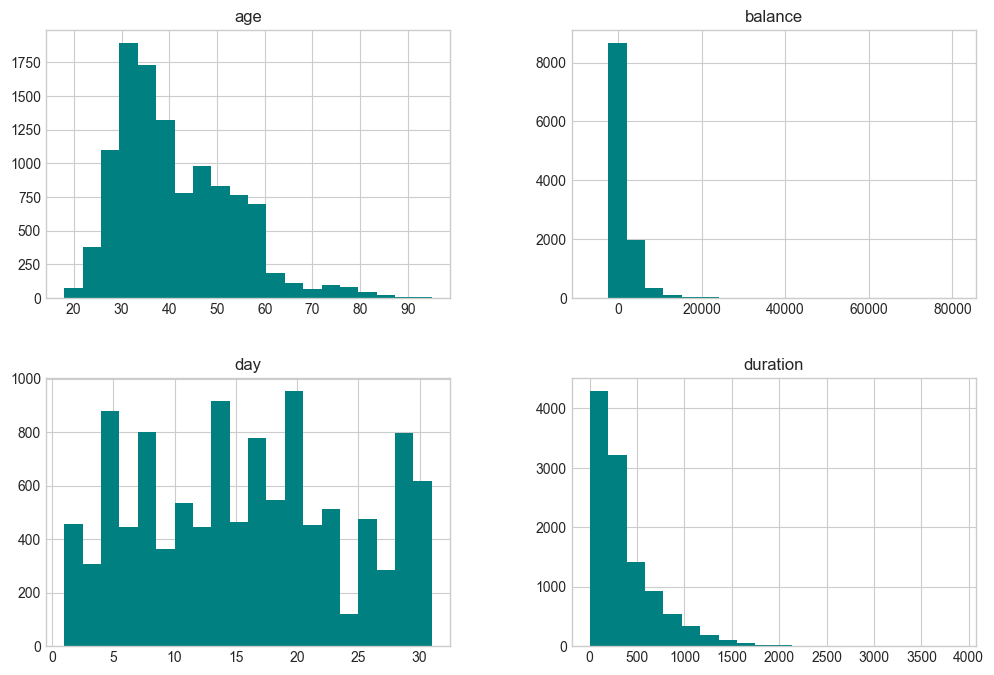

In [10]:
# Let's see how the numeric data is distributed.
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
cols=['age','balance','day','duration']
bank_df[cols].hist(bins=20, figsize=(12,8), color="teal")
plt.show()

Checking for outliers(balanc,duration)


In [11]:
# first changing the duration column into mins for better readability 
bank_df['duration_min']=bank_df['duration']/60
# now we  move for the outliers 

C:\Users\sania\AppData\Local\Temp\ipykernel_12436\2280528512.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="deposit",y="duration_min",data = bank_df ,palette="muted")


Text(0.5, 1.0, 'Call acceptance vs  duration time')

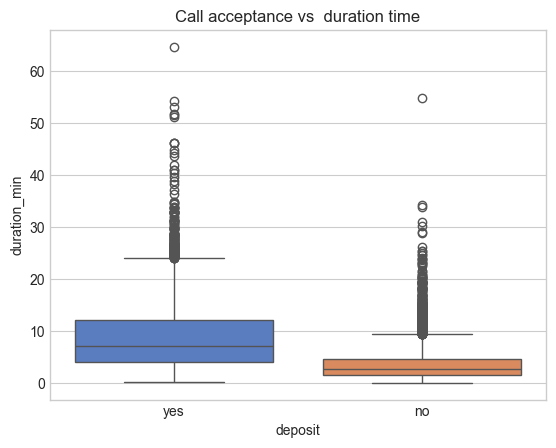

In [12]:
sns.boxplot(x="deposit",y="duration_min",data = bank_df ,palette="muted")
plt.title("Call acceptance vs  duration time")


Observation:Most customers who accepted the deposit (yes) had longer call durations, indicating that more engagement increases the likelihood of acceptance. There is one exception—a customer who did not accept (no) despite a long call. This customer can be considered an outlier, showing that while longer calls generally help, they do not guarantee a positive response

C:\Users\sania\AppData\Local\Temp\ipykernel_12436\429399631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="deposit",y="balance",data = bank_df ,palette="muted")


Text(0.5, 1.0, 'Call acceptance vs  duration time')

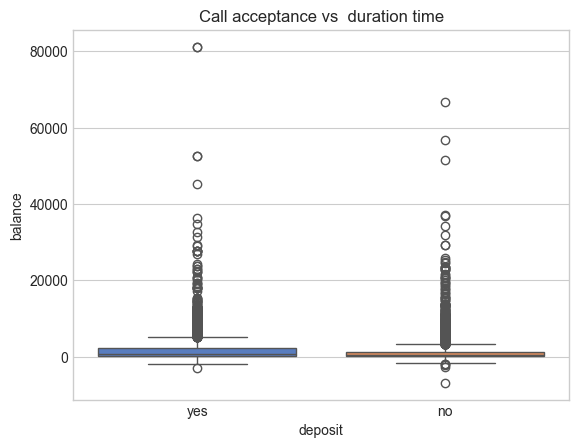

In [13]:
# for balance 
sns.boxplot(x="deposit",y="balance",data = bank_df ,palette="muted")
plt.title("Call acceptance vs  duration time")


Observation:Most customers with a balance of 40,000–60,000 are likely to accept the deposit. One outlier has a balance of 80,000 and also accepted. Customers who rejected the offer mostly have a balance below 40,000, with only a few exceptions


Now we have completed our step one lets  move to step 2 
Step 2: EDA (Exploratory Data Analysis)


Comparison deposit vs job

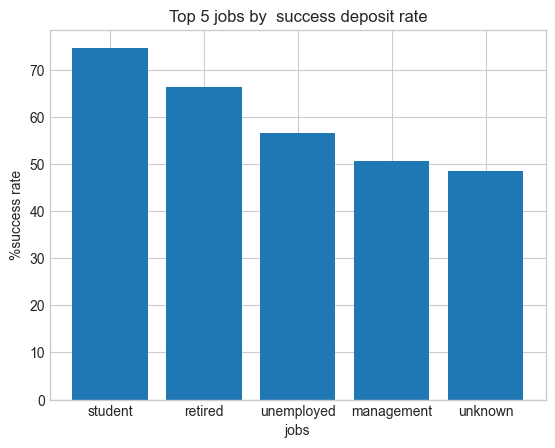

In [18]:
total=bank_df.groupby("job")['deposit'].count()
yes=bank_df[bank_df['deposit']=="yes"].groupby("job")['deposit'].count()
success_rate = (yes / total) * 100
top_5 = success_rate.sort_values(ascending=False).head(5)
plt.bar(top_5.index,top_5.values)
plt.title("Top 5 jobs by  success deposit rate")
plt.xlabel("jobs")
plt.ylabel("%success rate")
plt.show()

Students have the highest deposit success rate, followed by retired individuals. This indicates that these segments are more likely to respond positively to deposit offers. Therefore, the business should focus more on students by introducing targeted campaigns such as student-specific deals or benefits.

marital status vs loan 

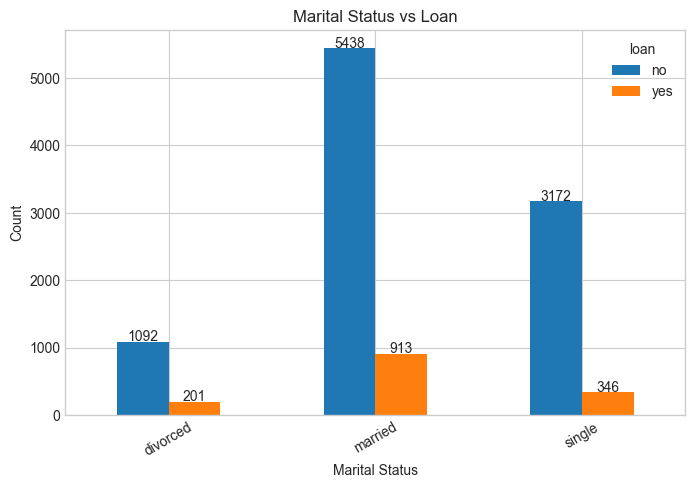

In [40]:
marital_loan = bank_df.groupby('marital')['loan'].value_counts().unstack()
ax = marital_loan.plot(kind='bar', figsize=(8,5))

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height()+5, str(int(i.get_height())),ha="center")

plt.title("Marital Status vs Loan")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

“observtion:This suggests that married individuals may have more financial stability or need, making them more likely to accept loan offers.”

3. Data Preprocessing
Adding featuring column

In [56]:
bins=[18,25,36,50,100]
bank_df['age_category']=pd.cut(bank_df['age'],bins=bins,labels=['youth','adult','middle Age','senior'],right=False)

In [57]:
bank_df['overdraft']=np.where(bank_df['balance'] < 0,1,0)

making  target variable (loan) into numeric for model

In [ ]:
bank_df['loan_numeric']=np.where(bank_df['loan']== "yes" ,1 , 0 )


Step 4. Train-Test Split

In [62]:
from sklearn.model_selection import train_test_split

# Features
X = bank_df[['age', 'job', 'marital', 'education', 'default', 'balance', 
             'housing', 'contact', 'day', 'month', 'duration', 'campaign', 
             'pdays', 'previous', 'poutcome', 'overdraft']]

# Target
y = bank_df['loan_numeric']

# Convert categorical columns to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 5 :Model Training

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

C:\Users\sania\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

step 6 :evaluating model

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Optional: Detailed classification report
print(classification_report(y_test, y_pred))
# Predictions
y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt*100:.2f}%")

cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Decision Tree Confusion Matrix:")
print(cm_dt)

print(classification_report(y_test, y_pred_dt))

Observation:High overall accuracy (87.6%): The model predicts the majority “no” responses very well.
Confusion in predicting “yes” (loan acceptance): Out of 273 actual “yes” cases, the model predicts only 9 correctly recall for “yes” is extremely low (0.03).
Precision for “yes” (0.43): When the model predicts “yes,” it’s correct less than half the time.
Imbalance effect: Most customers reject the loan, so the model is biased toward predicting “no.”